In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:

def make_toy_data(n=400, std=1.0, seed=0):
    rng = np.random.default_rng(seed)
    n0 = n//2
    n1 = n - n0
    X0 = rng.normal(loc=[-2, 0], scale=std, size=(n0, 2))
    X1 = rng.normal(loc=[ 2, 0], scale=std, size=(n1, 2))
    X = np.vstack([X0, X1])
    y = np.vstack([np.zeros((n0,1)), np.ones((n1,1))])
    idx = rng.permutation(n)
    return X[idx], y[idx]

In [3]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

In [4]:
def bce(yhat, y_tr, eps=1e-12):
    yhat = np.clip(yhat, eps, 1-eps)
    return -np.mean(y_tr*np.log(yhat) + (1-y_tr)*np.log(1-yhat))

In [5]:
h = 8
lr = 0.1
epochs = 300

In [6]:
X, y = make_toy_data(n=600, std=1.0, seed=42)

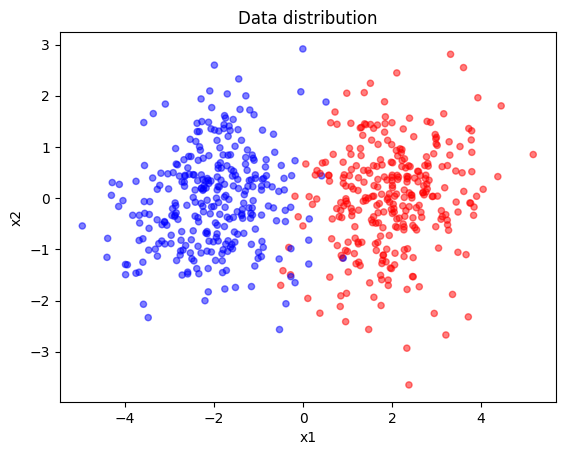

In [7]:
plt.scatter(X[:,0], X[:,1], c=y[:,0], s=20, cmap="bwr", alpha=0.5)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Data distribution")
plt.show()

In [8]:
N = X.shape[0]
idx = np.random.default_rng(0).permutation(N)
split = int(0.8 * N)
tr_idx, te_idx = idx[:split], idx[split:]

X_tr, y_tr = X[tr_idx], y[tr_idx]
X_te, y_te = X[te_idx], y[te_idx]

In [9]:
N_tr, d = X_tr.shape
rng = np.random.default_rng(1)
W1 = rng.normal(0, 0.1, size=(d, h))
b1 = np.zeros((1, h))
W2 = rng.normal(0, 0.1, size=(h, 1))
b2 = np.zeros((1, 1))

In [10]:
for ep in range(1, epochs+1):
    # forward
    z1 = X_tr @ W1 + b1               # (N,h)
    a1 = np.maximum(0.0, z1)       # ReLU
    z2 = a1 @ W2 + b2              # (N,1)
    yhat = sigmoid(z2)             # (N,1)

    loss = bce(yhat, y_tr)

    # backward (sigmoid+BCE: dL/dz2 = (yhat - y))
    dz2 = (yhat - y_tr) / N_tr           # ortalama
    dW2 = a1.T @ dz2               # (h,1)
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ W2.T               # (N,h)
    dz1 = da1 * (z1 > 0)           # ReLU türevi
    dW1 = X_tr.T @ dz1                # (d,h)
    db1 = np.sum(dz1, axis=0, keepdims=True)


    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if ep % 50 == 0 or ep == 1:
        preds = (yhat >= 0.5).astype(np.float32)
        acc = np.mean(preds == y_tr)
        print(f"epoch: {ep:3d} | loss: {loss:.4f} | acc: {acc*100:.1f}%")

epoch:   1 | loss: 0.6950 | acc: 35.2%
epoch:  50 | loss: 0.2867 | acc: 98.3%
epoch: 100 | loss: 0.0872 | acc: 98.3%
epoch: 150 | loss: 0.0617 | acc: 98.3%
epoch: 200 | loss: 0.0536 | acc: 98.3%
epoch: 250 | loss: 0.0500 | acc: 98.3%
epoch: 300 | loss: 0.0481 | acc: 98.3%


In [11]:
def predict_proba(X_in, W1, b1, W2, b2):
    z1 = X_in @ W1 + b1
    a1 = np.maximum(0.0, z1)
    z2 = a1 @ W2 + b2
    return sigmoid(z2)

In [12]:
# TEST
yhat_te = predict_proba(X_te, W1, b1, W2, b2)
preds_te = (yhat_te >= 0.5).astype(np.float32)

test_acc = np.mean(preds_te == y_te)
test_loss = bce(yhat_te, y_te)
print("-"*40)
print(f"TEST       | loss: {test_loss:.4f} | acc: {test_acc*100:.1f}%")

----------------------------------------
TEST       | loss: 0.0764 | acc: 95.8%


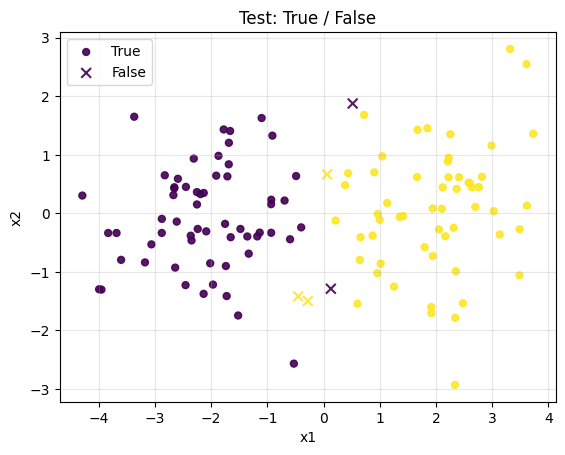

In [13]:
correct = (preds_te == y_te).ravel()
plt.figure()
plt.scatter(X_te[correct,0],  X_te[correct,1],  c=y_te[correct].ravel(), s=25, marker='o', alpha=0.9, label="True")
plt.scatter(X_te[~correct,0], X_te[~correct,1], c=y_te[~correct].ravel(), s=50, marker='x', alpha=0.9, label="False")
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Test: True / False")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()